# Genetic algorithms
Inspired by the core principles of Darwinian evolution.

- **Heredity**: There must be a mechanism that allows parent creatures in one generation to pass their traits down to child creatures in the next generation.
- **Variation**: There must be a variety of traits present in the population of creatures or a means to introduce variation for evolution to take place.
- **Selection**: There must be a mechanism by which some creatures have the opportunity to be parents and pass on their genetic information, while others don’t. This is commonly referred to as *survival of the fittest*.

## Steps

1. Create a random population of N elements (Variation)
2. Evaluate fitness of each element (Selection)
3. Reproduction (Heredity)
   1. Pick parents
   2. Crossover - create a child by combining two parents
   3. Mutate new child based on a given probability

## Parameters

- **`target`**: The string the algorithm is trying to evolve toward.
- **`mutation_rate`**: Probability (0–1) that any single gene is randomly replaced during reproduction. At `0.01`, each character has a 1% chance of mutating — low enough to preserve good traits, high enough to escape local optima.
- **`population_size`**: Number of individuals per generation. Larger populations increase diversity but slow each generation.

In [1]:
target = "To be or not to be."
mutation_rate = 0.01
population_size = 500

## Gene representation

Each individual's DNA is a list of characters (`genes`) with the same length as the target string. `new_random_char` samples uniformly from all printable ASCII characters, used to initialize genes and to apply mutations.

In [2]:
import math
import random
import string

def new_random_char():
    all_characters = string.ascii_letters + string.digits + string.punctuation + ' '
    return random.choice(all_characters)

## DNA class

Represents a single individual in the population.

- **`calc_fitness`**: Counts how many characters match the target, divides by the target length, then **squares** the result. Squaring amplifies the difference between high- and low-fitness individuals, creating stronger selection pressure toward better solutions.
- **`reproduce`**: Implements **single-point crossover** — the child inherits genes from `self` up to the midpoint, and from `partner` after. Each gene is then independently mutated with probability `mutation_rate`.

In [3]:
class DNA:
    def __init__(self, target, mutation_rate):
        self.target = target
        self.mutation_rate = mutation_rate
        self.genes = []
        self.create_random_genes()
        self.fitness = 0

    def __str__(self):
        return "".join(self.genes)

    def create_random_genes(self):
        self.genes = [new_random_char() for _ in range(len(target))]
    
    def calc_fitness(self):
        score = 0
        for i in range(len(self.genes)):
            if self.genes[i] == self.target[i]:
                score += 1
        self.fitness = (score / len(self.target)) ** 2

    def reproduce(self, partner):
        child = DNA(self.target, self.mutation_rate)
        midpoint = len(self.target) // 2
        child.genes = self.genes[:midpoint] + partner.genes[midpoint:]
        # mutate
        for i in range(len(child.genes)):
            if random.random() <= self.mutation_rate:
                child.genes[i] = new_random_char()
        child.calc_fitness()
        return child

## Population class

Manages the collection of individuals and runs the evolutionary loop.

- **`natural_selection`**: Builds a mating pool using **fitness-proportionate selection** (roulette wheel). Each individual is added `floor(fitness * 100)` times, so fitter individuals are proportionally more likely to be chosen as parents.
- **`mate`**: Randomly picks two parents from the mating pool and produces a child via `reproduce`. Repeats until the next generation is full (`population_size` children). Sets `done = True` when a perfect match is found.
- **`evaluate`**: Computes average and best fitness for the generation. Appends to `avg_fitness_history`, `best_fitness_history`, and `best_phrase_history` — used later to visualize convergence. Set `verbose=True` to print progress.

In [4]:
class Population:
    def __init__(self, target, mutation_rate, population_size):
        self.target = target
        self.mutation_rate = mutation_rate
        self.population_size = population_size
        self.population = []
        self.create_population()
        self.generation = 0
        self.mating_pool = []
        self.done = False
        self.avg_fitness_history = []
        self.best_fitness_history = []
        self.best_phrase_history = []

    def create_population(self):
        new_gen = []
        for _ in range(self.population_size):
            dna = DNA(self.target, self.mutation_rate)
            dna.calc_fitness()
            new_gen.append(dna)
        self.population = new_gen

    def natural_selection(self):
        new_mating_pool = []
        for dna in self.population:
            times = math.floor(dna.fitness * 100)
            new_mating_pool += [dna for _ in range(times)]
        # Fallback: if all fitness scores are too low to fill the pool,
        # allow everyone to mate so the loop doesn't crash.
        self.mating_pool = new_mating_pool if new_mating_pool else self.population[:]

    def mate(self):
        next_gen = []
        for _ in range(self.population_size):
            parent1 = random.choice(self.mating_pool)
            parent2 = random.choice(self.mating_pool)
            child = parent1.reproduce(parent2)
            if child.fitness == 1:
                self.done = True
            next_gen.append(child)
        self.population = next_gen
        self.generation += 1

    def evaluate(self, verbose=False):
        total_fitness = 0
        best = self.population[0]
        for dna in self.population:
            total_fitness += dna.fitness
            if dna.fitness > best.fitness:
                best = dna
        avg = total_fitness / self.population_size
        self.avg_fitness_history.append(avg)
        self.best_fitness_history.append(best.fitness)
        self.best_phrase_history.append(str(best))
        if verbose:
            print(f'Generation: {self.generation}, Average fitness: {round(avg, 2)}')
            print(f'Best phrase: {best}\n')

## Sanity checks

These cells manually construct two DNA instances with known genes and verify that `calc_fitness` and `reproduce` work correctly. `dna` and `dna2` each partially match `"racecar"`, and their child should combine the best of both halves.

In [5]:
dna = DNA('racecar', 0.01)
dna.genes = ['r','a','c','X','c','i','r']
dna.calc_fitness()
print(dna)
print(dna.fitness)

racXcir
0.5102040816326531


In [6]:
dna2 = DNA('racecar', 0.01)
dna2.genes = ['g','o','m','e','c','a','r']
dna2.calc_fitness()
print(dna2)
print(dna2.fitness)

gomecar
0.32653061224489793


In [7]:
dna3 = dna.reproduce(dna2)
print(dna3)
print(dna3.fitness)

racecar
1.0


## Running the simulation

Initialize a `Population` with the global parameters. The loop runs one full generation per iteration: build the mating pool → produce the next generation → check for completion. Progress is printed every 10 generations so you can observe how quickly the population converges on the target phrase.

In [8]:
population = Population(target, mutation_rate, population_size)

In [9]:
print(f'Population size: {population.population_size}, Mutation rate: {population.mutation_rate}')
while not population.done:
    population.natural_selection()
    population.mate()
    verbose = population.generation % 10 == 0 or population.generation == 1 or population.done
    population.evaluate(verbose=verbose)

Population size: 500, Mutation rate: 0.01
Generation: 1, Average fitness: 0.01
Best phrase: <B /? :[)PoZ-BTxld.

Generation: 10, Average fitness: 0.05
Best phrase: <B /e o[)n?~2tolqpA

Generation: 20, Average fitness: 0.13
Best phrase: TB /e o[)n?~2tolop~

Generation: 30, Average fitness: 0.16
Best phrase: TB /e o[)no22tolD+A

Generation: 40, Average fitness: 0.19
Best phrase: To /e o[)no~#tolo+=

Generation: 50, Average fitness: 0.24
Best phrase: To /e or)no~2tolK+=

Generation: 60, Average fitness: 0.27
Best phrase: To /e or)no~2to o+=

Generation: 70, Average fitness: 0.3
Best phrase: To /e orxno~2to o+=

Generation: 80, Average fitness: 0.33
Best phrase: To /e ortno~2to o+=

Generation: 90, Average fitness: 0.35
Best phrase: To <e orAnon2to o+f

Generation: 100, Average fitness: 0.35
Best phrase: To /e or)no#2to b+=

Generation: 110, Average fitness: 0.35
Best phrase: To 5e or)no#2to b+=

Generation: 120, Average fitness: 0.36
Best phrase: To `e or)no#qto b+=

Generation: 130, Aver

## Fitness convergence

Plotting average and best fitness over all generations reveals how the population evolves. Notice the **sigmoid-like curve**: slow initial progress while the population explores randomly, then rapid improvement as good genes propagate through the mating pool, then a plateau as the last few characters snap into place.

The gap between average and best fitness shows **selection pressure** — a wider gap means a few elite individuals dominate reproduction.

The cell after plots **phrase evolution**: correct characters are highlighted green, incorrect ones red, with a progress bar showing how many characters are right.

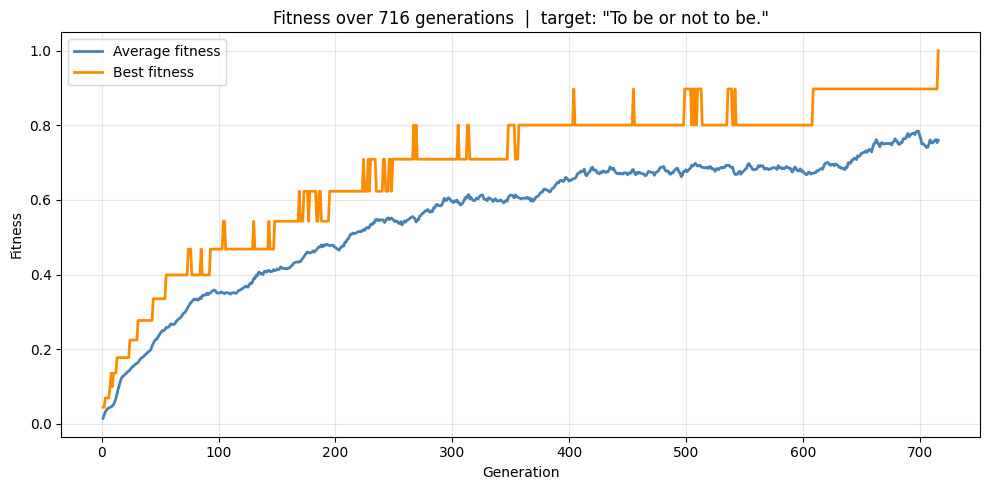

In [10]:
import matplotlib.pyplot as plt

gens = list(range(1, len(population.avg_fitness_history) + 1))

plt.figure(figsize=(10, 5))
plt.plot(gens, population.avg_fitness_history, label='Average fitness', color='steelblue', linewidth=2)
plt.plot(gens, population.best_fitness_history, label='Best fitness', color='darkorange', linewidth=2)
plt.xlabel('Generation')
plt.ylabel('Fitness')
plt.title(f'Fitness over {population.generation} generations  |  target: "{population.target}"')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
from IPython.display import HTML, display

def highlight_phrase(phrase, target):
    html = '<code style="font-size:14px;letter-spacing:1px">'
    for p, t in zip(phrase, target):
        if p == t:
            html += f'<span style="color:#27ae60;font-weight:bold">{p}</span>'
        else:
            html += f'<span style="color:#e74c3c">{p}</span>'
    html += '</code>'
    return html

n_samples = 14
total = len(population.best_phrase_history)
step = max(1, total // n_samples)
indices = list(range(0, total - 1, step)) + [total - 1]

display(HTML(f'<b>Target:</b> <code style="font-size:14px">{population.target}</code><br><br>'))
for i in indices:
    phrase = population.best_phrase_history[i]
    correct = sum(p == t for p, t in zip(phrase, population.target))
    bar = '█' * correct + '░' * (len(population.target) - correct)
    display(HTML(f'Gen {i+1:4d} [{bar}] {highlight_phrase(phrase, population.target)}<br>'))

## Effect of mutation rate

`mutation_rate` is one of the most important hyperparameters. The cell below runs the simulation four times with different rates and plots how the best fitness evolves.

| Rate | Effect |
|------|--------|
| Too low (`0.001`) | Population converges slowly or gets stuck — not enough variation to escape local optima |
| Just right (`0.01`) | Fast, reliable convergence |
| High (`0.05`) | Noisy convergence — good genes keep getting scrambled |
| Too high (`0.1`) | Essentially random search — genetic memory is destroyed each generation |

rate=0.001 → converged in 1262 generations
rate=0.010 → converged in  448 generations
rate=0.050 → did not converge after 2000 generations
rate=0.100 → did not converge after 2000 generations


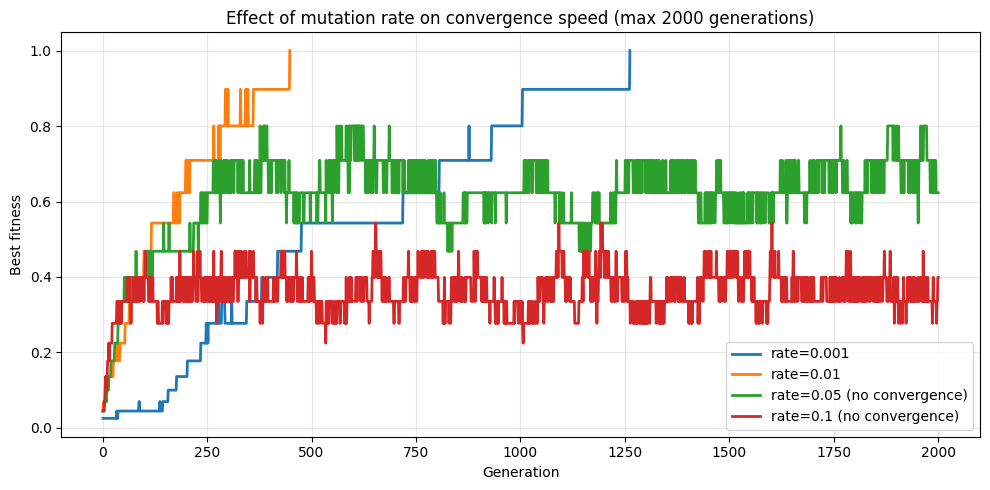

In [12]:
import matplotlib.pyplot as plt

mutation_rates = [0.001, 0.01, 0.05, 0.1]
max_generations = 2000
results = {}

for rate in mutation_rates:
    pop = Population(target, rate, population_size)
    while not pop.done and pop.generation < max_generations:
        pop.natural_selection()
        pop.mate()
        pop.evaluate()
    results[rate] = pop
    status = f'converged in {pop.generation:4d} generations' if pop.done else f'did not converge after {max_generations} generations'
    print(f'rate={rate:5.3f} → {status}')

plt.figure(figsize=(10, 5))
for rate in mutation_rates:
    pop = results[rate]
    gens = list(range(1, len(pop.best_fitness_history) + 1))
    label = f'rate={rate}' if pop.done else f'rate={rate} (no convergence)'
    plt.plot(gens, pop.best_fitness_history, label=label, linewidth=2)
plt.xlabel('Generation')
plt.ylabel('Best fitness')
plt.title(f'Effect of mutation rate on convergence speed (max {max_generations} generations)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Tournament selection

Roulette-wheel selection is **fitness-proportionate**: individuals with very low fitness can still be picked, just rarely. Early in evolution when all individuals have low fitness, selection pressure is nearly zero — parents are chosen almost at random.

**Tournament selection** avoids this: pick `k` random individuals, keep the winner. The fittest of the sample always wins, giving consistent selection pressure regardless of the absolute fitness values. Larger `k` = stronger pressure (only elites reproduce); smaller `k` = more exploration.

`run_simulation` is also defined here as a shared helper used by all subsequent exercises.

Roulette wheel:   829 generations
Tournament (k=5): 240 generations


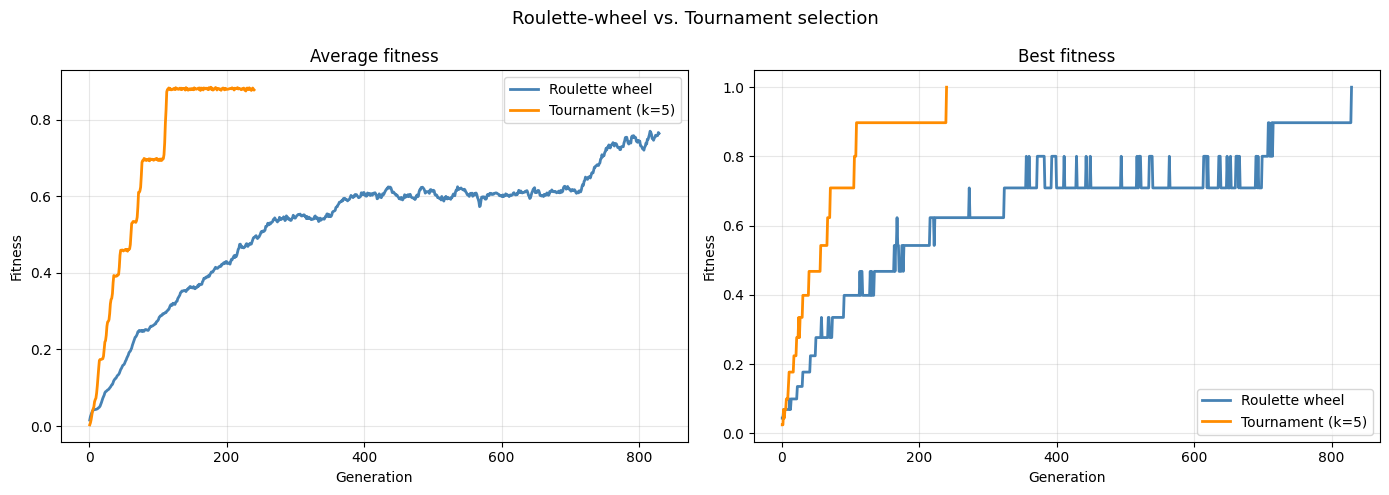

In [13]:
class TournamentPopulation(Population):
    """Uses tournament selection instead of roulette-wheel selection.

    Each parent is chosen by picking k random individuals and keeping
    the fittest. Higher k = stronger selection pressure (elites dominate),
    lower k = weaker pressure (more exploration).
    """

    def __init__(self, target, mutation_rate, population_size, k=5):
        self.k = k
        super().__init__(target, mutation_rate, population_size)

    def natural_selection(self):
        pass  # tournament selection happens inside mate()

    def mate(self):
        def tournament():
            competitors = random.sample(self.population, self.k)
            return max(competitors, key=lambda dna: dna.fitness)

        next_gen = []
        for _ in range(self.population_size):
            parent1 = tournament()
            parent2 = tournament()
            child = parent1.reproduce(parent2)
            if child.fitness == 1:
                self.done = True
            next_gen.append(child)
        self.population = next_gen
        self.generation += 1


def run_simulation(pop_class, max_generations=2000, **kwargs):
    pop = pop_class(target, mutation_rate, population_size, **kwargs)
    while not pop.done and pop.generation < max_generations:
        pop.natural_selection()
        pop.mate()
        pop.evaluate()
    return pop


roulette   = run_simulation(Population)
tournament = run_simulation(TournamentPopulation, k=5)

print(f'Roulette wheel:   {roulette.generation} generations')
print(f'Tournament (k=5): {tournament.generation} generations')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, attr, title in [
    (axes[0], 'avg_fitness_history', 'Average fitness'),
    (axes[1], 'best_fitness_history', 'Best fitness'),
]:
    for pop, label, color in [
        (roulette,   'Roulette wheel',   'steelblue'),
        (tournament, 'Tournament (k=5)', 'darkorange'),
    ]:
        gens = list(range(1, len(getattr(pop, attr)) + 1))
        ax.plot(gens, getattr(pop, attr), label=label, color=color, linewidth=2)
    ax.set_xlabel('Generation')
    ax.set_ylabel('Fitness')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Roulette-wheel vs. Tournament selection', fontsize=13)
plt.tight_layout()
plt.show()

## Elitism

Standard genetic algorithms can **lose** the best individual between generations — it might not be picked as a parent, or its offspring might mutate poorly, causing best fitness to temporarily *decrease*. **Elitism** fixes this by always copying the single fittest individual directly into the next generation unchanged.

Notice in the best-fitness plot that the elitist curve is strictly non-decreasing, while the baseline can occasionally dip.

Baseline: 335 generations
Elitist:  313 generations


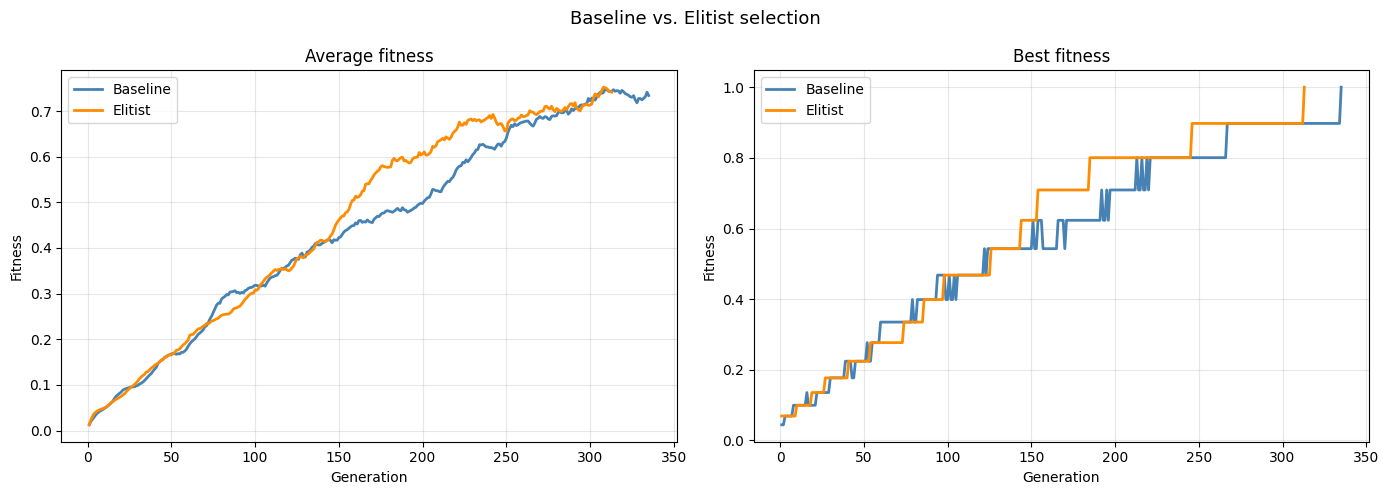

In [14]:
class ElitistPopulation(Population):
    """Always carries the single best individual unchanged into the next generation.

    This guarantees best fitness never decreases between generations.
    It also means the mating pool is always populated (the elite individual
    has a fitness > 0), avoiding the empty-mating-pool edge case.
    """

    def mate(self):
        best = max(self.population, key=lambda dna: dna.fitness)
        if best.fitness == 1:
            self.done = True

        next_gen = [best]  # elitist carry-over — unchanged
        for _ in range(self.population_size - 1):
            parent1 = random.choice(self.mating_pool)
            parent2 = random.choice(self.mating_pool)
            child = parent1.reproduce(parent2)
            if child.fitness == 1:
                self.done = True
            next_gen.append(child)

        self.population = next_gen
        self.generation += 1


baseline = run_simulation(Population)
elitist  = run_simulation(ElitistPopulation)

print(f'Baseline: {baseline.generation} generations')
print(f'Elitist:  {elitist.generation} generations')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, attr, title in [
    (axes[0], 'avg_fitness_history', 'Average fitness'),
    (axes[1], 'best_fitness_history', 'Best fitness'),
]:
    for pop, label, color in [
        (baseline, 'Baseline', 'steelblue'),
        (elitist,  'Elitist',  'darkorange'),
    ]:
        gens = list(range(1, len(getattr(pop, attr)) + 1))
        ax.plot(gens, getattr(pop, attr), label=label, color=color, linewidth=2)
    ax.set_xlabel('Generation')
    ax.set_ylabel('Fitness')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Baseline vs. Elitist selection', fontsize=13)
plt.tight_layout()
plt.show()

## Two-point crossover

Standard single-point crossover always splits at the midpoint: `child = parent1[:mid] + parent2[mid:]`. The first half always comes from parent1 and the second half from parent2 — genes in the middle can never be exchanged.

**Two-point crossover** picks two random cut points `a` and `b`, so the child inherits a contiguous block from parent2 surrounded by segments from parent1:

```
child = parent1[:a] + parent2[a:b] + parent1[b:]
```

This allows any genes to be inherited from either parent, producing more diverse combinations.

Single-point crossover: 687 generations
Two-point crossover:    285 generations


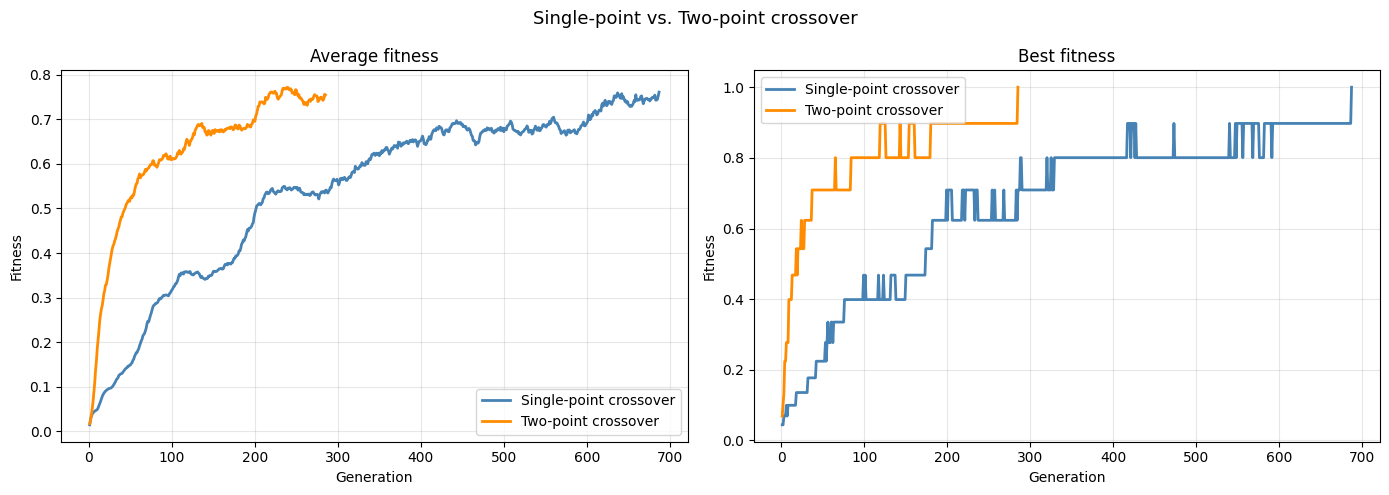

In [15]:
class TwoPointDNA(DNA):
    """Uses two random crossover points instead of a fixed midpoint.

    child = parent1[:a] + parent2[a:b] + parent1[b:]

    This lets a contiguous block of parent2's genes appear anywhere in
    the child, producing more diverse combinations than single-point crossover.
    """

    def reproduce(self, partner):
        child = TwoPointDNA(self.target, self.mutation_rate)
        a = random.randint(0, len(self.target))
        b = random.randint(a, len(self.target))
        child.genes = self.genes[:a] + partner.genes[a:b] + self.genes[b:]
        for i in range(len(child.genes)):
            if random.random() <= self.mutation_rate:
                child.genes[i] = new_random_char()
        child.calc_fitness()
        return child


class TwoPointPopulation(Population):
    def create_population(self):
        new_gen = [TwoPointDNA(self.target, self.mutation_rate) for _ in range(self.population_size)]
        for dna in new_gen:
            dna.calc_fitness()
        self.population = new_gen


baseline   = run_simulation(Population)
two_point  = run_simulation(TwoPointPopulation)

print(f'Single-point crossover: {baseline.generation} generations')
print(f'Two-point crossover:    {two_point.generation} generations')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, attr, title in [
    (axes[0], 'avg_fitness_history', 'Average fitness'),
    (axes[1], 'best_fitness_history', 'Best fitness'),
]:
    for pop, label, color in [
        (baseline,  'Single-point crossover', 'steelblue'),
        (two_point, 'Two-point crossover',    'darkorange'),
    ]:
        gens = list(range(1, len(getattr(pop, attr)) + 1))
        ax.plot(gens, getattr(pop, attr), label=label, color=color, linewidth=2)
    ax.set_xlabel('Generation')
    ax.set_ylabel('Fitness')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Single-point vs. Two-point crossover', fontsize=13)
plt.tight_layout()
plt.show()

## Adaptive mutation

A fixed `mutation_rate` is a compromise: high enough for early exploration, but the same rate later keeps scrambling genes that are already correct. **Adaptive mutation** ties the rate to the population's current fitness:

```
rate = base_rate × (1 − avg_fitness)
```

Early on (low fitness) the rate stays near `base_rate`. As the population converges, the rate shrinks toward zero, letting fine-tuning happen without destroying good genes.

Fixed mutation:    416 generations
Adaptive mutation: 976 generations


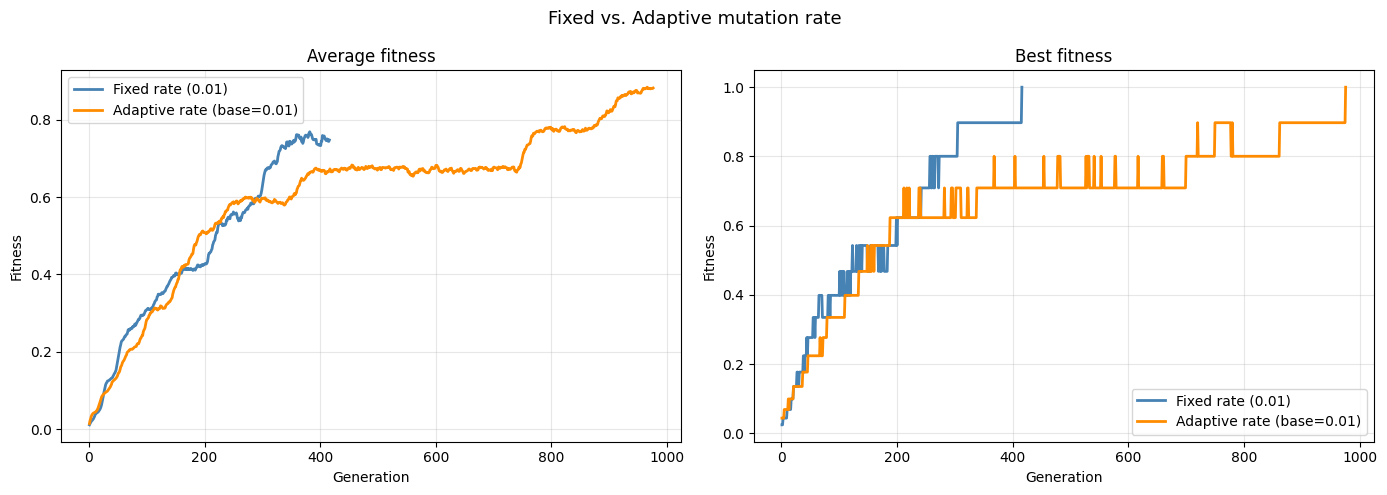

In [16]:
class AdaptiveMutationPopulation(Population):
    """Scales mutation_rate down as average fitness increases.

    rate = base_rate × (1 - avg_fitness)
    Early on (low fitness) the rate stays near base_rate for exploration.
    Later (high fitness) the rate shrinks, protecting well-evolved genes.
    """

    def __init__(self, target, mutation_rate, population_size):
        self.base_mutation_rate = mutation_rate
        super().__init__(target, mutation_rate, population_size)

    def mate(self):
        avg_fitness = sum(dna.fitness for dna in self.population) / self.population_size
        rate = self.base_mutation_rate * (1 - avg_fitness)

        next_gen = []
        for _ in range(self.population_size):
            parent1 = random.choice(self.mating_pool)
            parent2 = random.choice(self.mating_pool)
            child = DNA(self.target, rate)
            midpoint = len(self.target) // 2
            child.genes = parent1.genes[:midpoint] + parent2.genes[midpoint:]
            for i in range(len(child.genes)):
                if random.random() <= rate:
                    child.genes[i] = new_random_char()
            child.calc_fitness()
            if child.fitness == 1:
                self.done = True
            next_gen.append(child)
        self.population = next_gen
        self.generation += 1


baseline = run_simulation(Population)
adaptive = run_simulation(AdaptiveMutationPopulation)

print(f'Fixed mutation:    {baseline.generation} generations')
print(f'Adaptive mutation: {adaptive.generation} generations')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, attr, title in [
    (axes[0], 'avg_fitness_history', 'Average fitness'),
    (axes[1], 'best_fitness_history', 'Best fitness'),
]:
    for pop, label, color in [
        (baseline, f'Fixed rate ({mutation_rate})',              'steelblue'),
        (adaptive, f'Adaptive rate (base={mutation_rate})', 'darkorange'),
    ]:
        gens = list(range(1, len(getattr(pop, attr)) + 1))
        ax.plot(gens, getattr(pop, attr), label=label, color=color, linewidth=2)
    ax.set_xlabel('Generation')
    ax.set_ylabel('Fitness')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Fixed vs. Adaptive mutation rate', fontsize=13)
plt.tight_layout()
plt.show()

## Population size vs. generations

A larger population increases genetic **diversity** — less likely to get stuck in local optima — but each generation is more expensive to evaluate. Plotting `population_size` against generations to converge reveals the tradeoff: beyond a certain size there are diminishing returns.

The **total fitness evaluations** (`size × generations`) is the true measure of compute cost.

size=   50 → [2000, 2000, 2000]  (mean=2000)
size=  100 → [2000, 2000, 1466]  (mean=1822)
size=  200 → [1183, 1454, 720]  (mean=1119)
size=  500 → [513, 401, 311]  (mean=408)
size= 1000 → [505, 264, 283]  (mean=351)
size= 2000 → [268, 233, 253]  (mean=251)


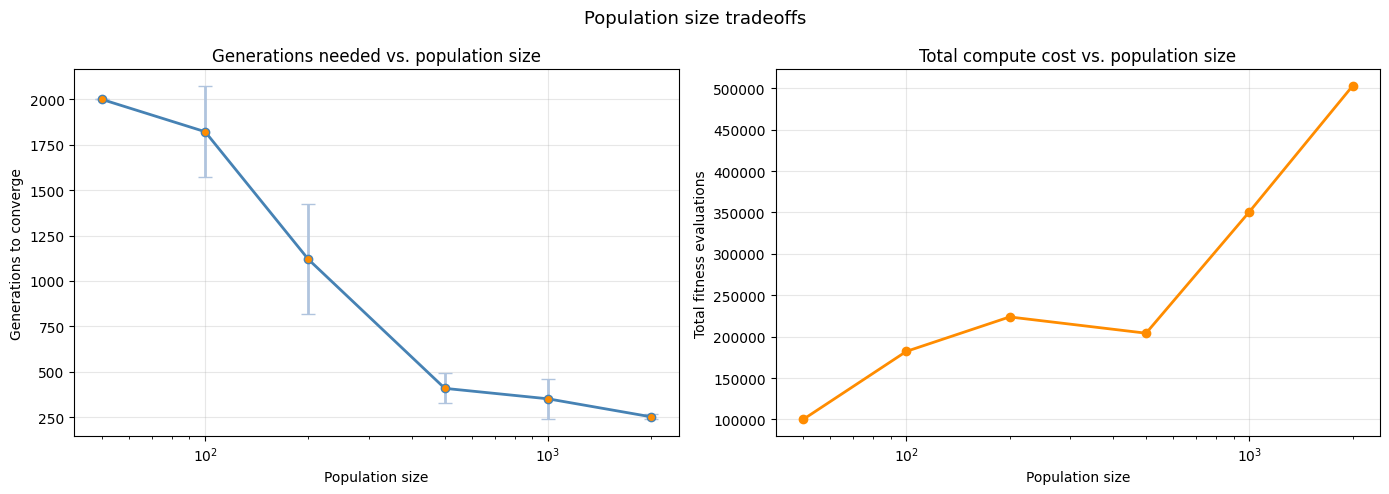

In [17]:
import numpy as np

sizes = [50, 100, 200, 500, 1000, 2000]
n_trials = 3       # average over multiple runs to reduce noise
max_generations = 2000

results_by_size = {}
for size in sizes:
    trial_gens = []
    for _ in range(n_trials):
        pop = Population(target, mutation_rate, size)
        while not pop.done and pop.generation < max_generations:
            pop.natural_selection()
            pop.mate()
            pop.evaluate()
        trial_gens.append(pop.generation)
    results_by_size[size] = trial_gens
    print(f'size={size:5d} → {trial_gens}  (mean={sum(trial_gens)/n_trials:.0f})')

means = [sum(v) / n_trials for v in results_by_size.values()]
stds  = [np.std(v) for v in results_by_size.values()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: generations to converge
axes[0].errorbar(sizes, means, yerr=stds, marker='o', linewidth=2, capsize=5,
                 color='steelblue', ecolor='lightsteelblue', markerfacecolor='darkorange')
axes[0].set_xlabel('Population size')
axes[0].set_ylabel('Generations to converge')
axes[0].set_title('Generations needed vs. population size')
axes[0].set_xscale('log')
axes[0].grid(True, alpha=0.3)

# Right: total fitness evaluations — the real compute cost
total_evals = [s * m for s, m in zip(sizes, means)]
axes[1].plot(sizes, total_evals, marker='o', linewidth=2, color='darkorange')
axes[1].set_xlabel('Population size')
axes[1].set_ylabel('Total fitness evaluations')
axes[1].set_title('Total compute cost vs. population size')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Population size tradeoffs', fontsize=13)
plt.tight_layout()
plt.show()